In [ ]:
                                       Nesterov Accelerated Gradient (NAG) Optimizer

In [ ]:
optimizer  ka kaam hota hai  ki model ke weight ko update karna taki loss("error") kam ho jaye
example => ap pahad par ho or high loss se neeche ja rahe ek vally(zero loss) ki taraf ja rahe ho optimizer wahi algoritham hai
jo decide karta hai kitne bade kadam steps lene hai taki rasta no bhatko.

In [ ]:
What is NAG:-
             Nesterov Accelerated Gradient (NAG) Optimizer momentum se thoda advanced hota hai. 
             Momentum optimizer mein, hum previous gradient ke saath velocity add karte hain, 
             taaki optimization fast ho sake aur local minima se bach sake.
            NAG mein hum velocity ko pehle predict karte hain (ek step aage ka sochte hain), phir actual gradient ka calculation karte hain.
            Is approach ki wajah se hum better direction mein move karte hain, aur humko clearer pata lagta hai ki agle step mein kahan jaana chahiye.

NAG ka fayda:-
                NAG pehle predict kar leta hai ki kahan jaana hai, isliye hum correct direction mein better adjust karte hain. 
                Prediction ke baad gradient calculate karte hain taaki exact update ho sake.

In [ ]:
Momentum ka drawback:-
                    Momentum bas peechle step ke velocity pe depend karta hai, jisse thoda zyada overshoot ho sakta hai ya wrong 
                    direction mein jaane ka chance ho sakta hai.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
df = pd.read_csv(r"C:\Users\Lenovo\Desktop\gaurav\titanic.csv")
df.head()
df = df.drop(columns=["Name","Ticket","Cabin"],axis=1)
df["Age"].fillna(df["Age"].mean(),inplace=True)
df["Fare"].fillna(df["Fare"].mean(),inplace=True)
df["Embarked"].fillna(df["Embarked"].mode(),inplace=True)
l = LabelEncoder()
df["Embarked"]= l.fit_transform(df["Embarked"])
df["Sex"]= l.fit_transform(df["Sex"])
X = df.drop("Survived",axis=1)
y = df["Survived"]


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4564\3229598609.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4564\3229598609.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [2]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
s = StandardScaler()
X_train_scaled = s.fit_transform(X_train)
X_test_scaled = s.transform(X_test)

In [4]:
def create_model():
    model = Sequential()
    model.add(Dense(64,input_dim=X_train_scaled.shape[1],activation="relu"))
    model.add(Dense(32,activation="relu"))
    model.add(Dense(1,activation="sigmoid"))
    return model

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Sequential name=sequential, built=True>

In [16]:
model_momentam = create_model()
model_optimizer = SGD(learning_rate=0.01, momentum=0.9)
model_momentam.compile(optimizer=model_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
# Train model
history_momentum = model_momentam.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)
"""
1. verbose Kya Hai?
verbose ka matlab hota hai "Report dena" ya "Batuni hona".
Jab aap model train karte hain, toh aap computer ko bata rahe hote hain ki training ke waqt screen par kitni detail dikhani hai. Iska training ki quality se koi lena-dena nahi hai, yeh sirf aapke (user) dekhne ke liye hai.

Ismein aam taur par teen options hote hain:

verbose=0: Bilkul khamosh (Silent mode). Screen par kuch nahi dikhega jab tak training khatam na ho jaye. (Aapki image mein yahi use hua hai).

verbose=1: Sabse zyada detail. Har epoch ke liye ek progress bar dikhayega.

verbose=2: Beech ka rasta. Har epoch ke baad sirf ek line likh kar aayegi (Progress bar nahi dikhega)."""

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


'\n1. verbose Kya Hai?\nverbose ka matlab hota hai "Report dena" ya "Batuni hona".\nJab aap model train karte hain, toh aap computer ko bata rahe hote hain ki training ke waqt screen par kitni detail dikhani hai. Iska training ki quality se koi lena-dena nahi hai, yeh sirf aapke (user) dekhne ke liye hai.\n\nIsmein aam taur par teen options hote hain:\n\nverbose=0: Bilkul khamosh (Silent mode). Screen par kuch nahi dikhega jab tak training khatam na ho jaye. (Aapki image mein yahi use hua hai).\n\nverbose=1: Sabse zyada detail. Har epoch ke liye ek progress bar dikhayega.\n\nverbose=2: Beech ka rasta. Har epoch ke baad sirf ek line likh kar aayegi (Progress bar nahi dikhega).'

In [ ]:
model_momentum = create_model()

Yahan pe hum create_model() function ko call karke apna model bana rahe hain. Yeh function ek neural network model banata hai jisme layers hoti hain jaisa ki humne pehle discuss kiya tha.

momentum_optimizer = SGD(learning_rate=0.01, momentum=0.9) (Momentum Optimizer Banana)

Humne SGD (Stochastic Gradient Descent) optimizer ko use kiya hai, lekin isme momentum add kiya hai.

learning_rate=0.01: Yeh define karta hai ki har update step kitna chhota ya bada hoga (learning rate 0.01 hai).

momentum=0.9: Yeh momentum factor hai. Momentum ka kaam previous gradients ko store karke optimization ko fast karna hota hai, taaki hum smoother aur faster convergence paa sakein.

model_momentum.compile(optimizer=momentum_optimizer, loss='binary_crossentropy', metrics=['accuracy']) (Model Ko Compile Karna)

Optimizer: momentum_optimizer ko humne optimizer ke tarah use kiya hai. Yani, model weights ko update karne ke liye momentum-based optimizer use karega.

Loss function: binary_crossentropy loss function use ho raha hai, kyunki Titanic dataset ek binary classification problem hai (Survived ya Not Survived).

Metrics: metrics=['accuracy'] ka matlab hai ki training ke dauran hum accuracy ko track kar rahe hain, taaki hume pata chale ki model kitna accurate hai.

history_momentum = model_momentum.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)

X_train aur y_train: Yeh training data aur labels hain. Model inko use karke seekhne ki koshish karega.

validation_data=(X_test, y_test): Yeh validation ke liye test data hai. Training ke baad, har epoch ke baad, model apna performance test data pe check karega.

epochs=100: Yani model ko 100 times (epochs) tak training data pe train karna hai.

batch_size=32: Iska matlab har baar 32 samples ka mini-batch liya jayega aur us par weight update kiya jayega.

verbose=0: Training process ke dauran koi output nahi dikhaya jayega (silent mode).

In [18]:
# NAG Optimizer
model_nag = create_model()
nag_optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

model_nag.compile(optimizer=nag_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history_nag = model_nag.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32, verbose=0)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


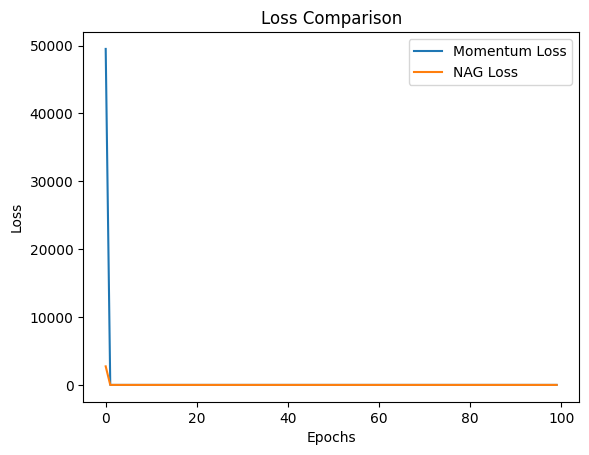

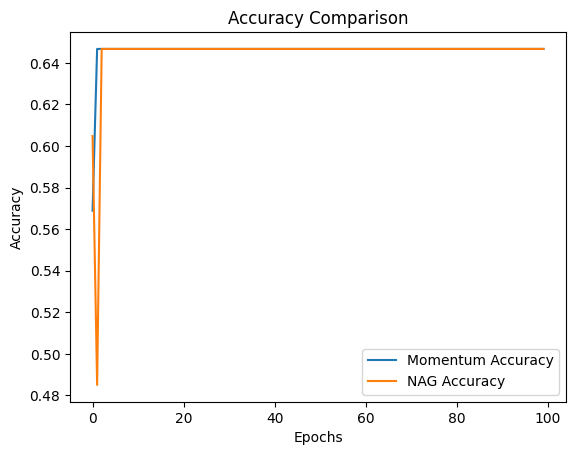

In [19]:
import matplotlib.pyplot as plt

# Plotting Losses
plt.plot(history_momentum.history['loss'], label='Momentum Loss')
plt.plot(history_nag.history['loss'], label='NAG Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plotting Accuracy
plt.plot(history_momentum.history['accuracy'], label='Momentum Accuracy')
plt.plot(history_nag.history['accuracy'], label='NAG Accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()